In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#simpeg Imports -- For forward problem
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import maps

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import tarfile
from pathlib import Path

mpl.rcParams.update({"font.size": 14}) #(No Idea..)

#Simpeg imports -- Not for forward problem
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

import sys
sys.path.append("../src")

import init_utils


save_output = False  # Optional, (No Idea..)

#Fix path to data directory
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "raw"

### Read in data
We have four data files:
- obs.mag
- sus.mod
- sus.msh
- topo.dat

obs.mag is five columns organized as the following (containing total field oberservations):

X       Y       Z       DATA_VALUE    ERROR

sus.mod is one column of susceptibiity values

sus.msh decribes the tensor mesh

topo.dat is three columns, describing the topography as such:

X       Y       Z 

In [ ]:
#Load data
observations = init_utils.read_obs_mag("obs.mag")
mesh_data = init_utils.read_tensor_mesh(DATA_DIR / "sus.msh")
data = init_utils.load_cache("upward_data")

dobs_upward_continued = data["dobs"]
errors = data["errors"]


#Load topography and active cells
topo_and_active_cells = init_utils.load_cache("topo_and_active")

topography = topo_and_active_cells["topography"]
active_cells = topo_and_active_cells["active_cells"]

#Load survey info
Surver_info = init_utils.load_cache("survey_info")

receiver_locations_good = Surver_info["receivers"]
amplitude = Surver_info["amplitude"]
inclination = Surver_info["inclination"]
declination = Surver_info["declination"]


### Define Survey

In [ ]:
up_receiver_list = magnetics.receivers.Point(receiver_locations_good, components=["tmi"])
up_source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=[up_receiver_list],
    amplitude=amplitude, inclination=inclination, declination=declination
)
up_survey = magnetics.survey.Survey(up_source_field)

up_sim = magnetics.simulation.Simulation3DIntegral(
    survey=up_survey, mesh=tensor_mesh, chiMap=eq_model_map, 
    active_cells=eq_active_cells, model_type="scalar"
)

In [ ]:
# print(observations.shape)
# print(topography.shape)
# print(mesh_data)

(2009, 5)
(2009, 3)
{'nx': 48, 'ny': 40, 'nz': 36, 'x0': 12300.0, 'y0': 9000.0, 'z0': 1150.0, 'dx': 25.0, 'dy': 25.0, 'dz': 12.5}


### Plot Topography

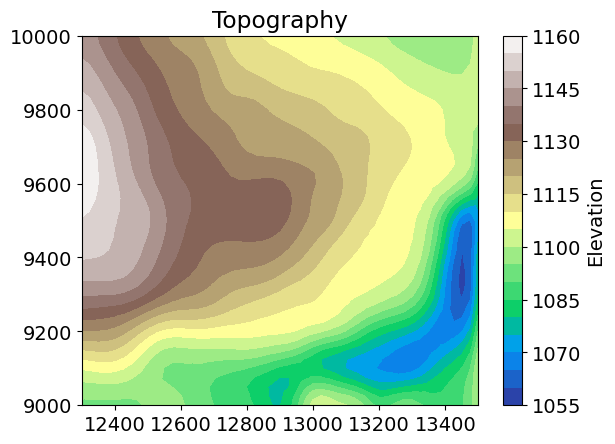

In [ ]:
x_topo = topography['X'].values
y_topo = topography['Y'].values
z_topo = topography['Z'].values

plt.tricontourf(x_topo, y_topo, z_topo, levels=20, cmap="terrain")
plt.colorbar(label="Elevation")
# plt.scatter(x_topo, y_topo, c="k", s=1)
plt.title("Topography")
plt.show()

                      

### Define Observation locations

In [ ]:
#For a ground survey (like Mt. Milligan), topo and observation locations are the same except spaced out. 
#Sampled every 10 meters, on surface.
x_obs = observations['X'].values
y_obs = observations['Y'].values

fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z_obs = fun_interp(np.c_[x_obs, y_obs])  

mask = ~np.isnan(z_obs) #be careful of NANs from the interpolation
receiver_locations_inital = np.c_[x_obs[mask], y_obs[mask], z_obs[mask]] 


In [ ]:
# # Define the component(s) of the field we want to simulate as a list of strings.
# # Here we simulation total magnetic intensity data.
# components = ["tmi"]

# # Use the observation locations and components to define the receivers. To
# # simulate data, the receivers must be defined as a list.
# receiver_list = magnetics.receivers.Point(receiver_locations, components=components) #List of receivers from locations
# receiver_list = [receiver_list]

# # Define the inducing field
# inclination = 75  # inclination [deg]
# declination = 25.73  # declination [deg]
# amplitude = 58193  # amplitude [nT]

# source_field = magnetics.sources.UniformBackgroundField(
#     receiver_list=receiver_list,
#     amplitude=amplitude,
#     inclination=inclination,
#     declination=declination,
# )

# # Define the survey
# survey = magnetics.survey.Survey(source_field)

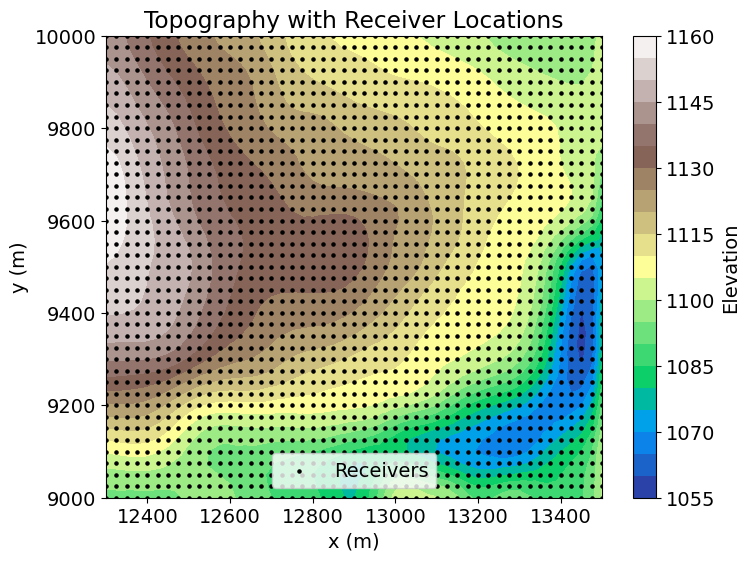

In [ ]:
# plt.figure(figsize=(8, 6))

# # Topography
# plt.tricontourf(x_topo, y_topo, z_topo, levels=20, cmap="terrain")
# plt.colorbar(label="Elevation")

# # Receiver locations (projected to x-y)
# plt.scatter(
#     receiver_locations[:, 0],
#     receiver_locations[:, 1],
#     c="k",
#     s=5,
#     label="Receivers"
# )

# plt.title("Topography with Receiver Locations")
# plt.xlabel("x (m)")
# plt.ylabel("y (m)")
# plt.legend()

# plt.show()

 ### Define Tensor Mesh

In [8]:
nx, ny, nz = mesh_data["nx"], mesh_data["ny"], mesh_data["nz"]
dx, dy, dz = mesh_data["dx"], mesh_data["dy"], mesh_data["dz"]
x0, y0, z0 = mesh_data["x0"], mesh_data["y0"], mesh_data["z0"]

# x_mesh = [(dx, nx)] #No padding, active cells and ref model mismatch...
# y_mesh = [(dy, ny)]
# z_mesh = [(dz, nz)]

x_mesh = [(dx, 5, -1.3), (dx, nx), (dx, 5, 1.3)] 
y_mesh = [(dy, 5, -1.3), (dy, ny), (dy, 5, 1.3)]
z_mesh = [(dz, 5, -1.3), (dz, nz)]

tensor_mesh = TensorMesh([x_mesh, y_mesh, z_mesh], "CCN")

hx, hy, hz = tensor_mesh.h

tensor_mesh.origin = np.r_[
    x0 - np.sum(hx[:5]),
    y0 - np.sum(hy[:5]),
    z0 - np.sum(hz),
]

#Unpadded shift
# # Shift origin so that nodes match the UBC mesh definition
# tensor_mesh.origin = np.r_[
#     x0,              # nodes_x[0] = x0
#     y0,              # nodes_y[0] = y0
#     z0 - nz * dz,    # nodes_z[0] = z0 - nz*dz, nodes_z[-1] ≈ z0
# ]

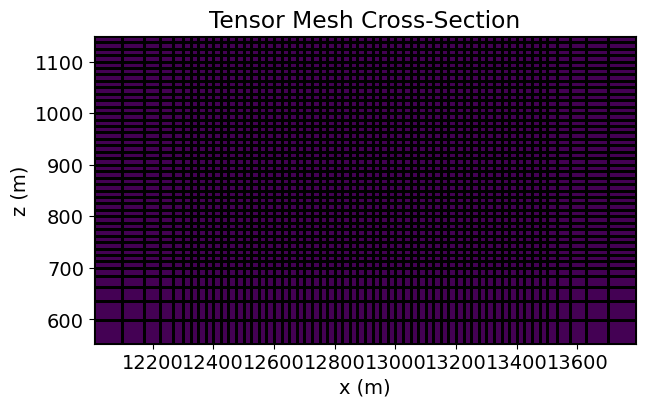

In [9]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)

# Plot a vertical slice through the mesh
tensor_mesh.plot_slice(
    np.ones(tensor_mesh.nC),  # dummy model (just to show cells)
    normal="Y",               # slice direction
    ind=int(tensor_mesh.shape_cells[1] / 2),
    ax=ax,
    grid=True,
)

ax.set_title("Tensor Mesh Cross-Section")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")

plt.show()

 ### Map active cells 

In [ ]:
# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active) #simpeg identity map

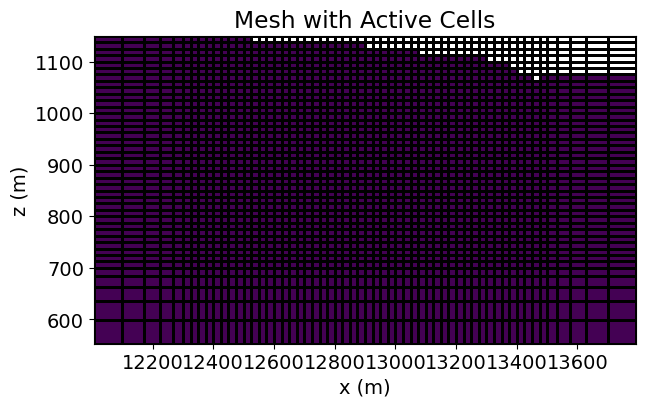

In [13]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)

active_plot = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

tensor_mesh.plot_slice(
    active_plot * np.ones(n_active),
    normal="Y",
    ind=int(tensor_mesh.shape_cells[1] / 2),
    ax=ax,
    grid=True,
    pcolor_opts={"cmap": "viridis"},
)

ax.set_title("Mesh with Active Cells")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")

plt.show()

### Define Forward Simulation (Raw Data)

In [ ]:
# initial_simulation = magnetics.simulation.Simulation3DIntegral(
#     survey=survey,
#     mesh=tensor_mesh,
#     model_type="scalar",
#     chiMap=model_map,
#     active_cells=active_cells,
#     store_sensitivities="forward_only",
#     engine="choclo",
# )

### Define data and errors (raw data)

In [ ]:
# dobs_full = observations['MAG'].values
# errors_full = observations['ERR'].values
# dobs = dobs_full[mask]
# errors = errors_full[mask]

# # --- NEW BLOCK: detect and drop bad dpred point ---
# starting_tensor_model = 1e-4 * np.ones(n_active)

# dpred0 = initial_simulation.dpred(starting_tensor_model)
# good = ~np.isnan(dpred0)

# # Filter receivers and data
# receiver_locations_good = receiver_locations_initial[good]
# dobs_good = dobs[good]
# errors_good = errors[good]

# # Rebuild receiver list, source field, survey
# receiver_list = magnetics.receivers.Point(
#     receiver_locations_good, components=["tmi"]
# )
# source_field = magnetics.sources.UniformBackgroundField(
#     receiver_list=[receiver_list],
#     amplitude=amplitude,
#     inclination=inclination,
#     declination=declination,
# )
# survey = magnetics.survey.Survey(source_field)

# # Rebuild simulation with cleaned survey
# simulation = magnetics.simulation.Simulation3DIntegral(
#     survey=survey,
#     mesh=tensor_mesh,
#     model_type="scalar",
#     chiMap=model_map,
#     active_cells=active_cells,
#     store_sensitivities="forward_only",
#     engine="choclo",
# )

# # Replace dobs/errors with cleaned versions
# dobs = dobs_good
# errors = errors_good

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Visualize raw data

In [ ]:
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)

# # Symmetric color scale
# vmax = np.max(np.abs(dobs))
# norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

# # --- Filled contours (SimPEG) ---
# cplot = plot2Ddata(
#     receiver_locations_inital[:, :2],
#     dobs,
#     ax=ax,
#     ncontour=30,
#     contourOpts={"cmap": "bwr", "norm": norm},
# )

# # --- Interpolate to grid for contour lines ---
# from scipy.interpolate import griddata

# x = receiver_locations_inital[:, 0]
# y = receiver_locations_inital[:, 1]

# xi = np.linspace(x.min(), x.max(), 100)
# yi = np.linspace(y.min(), y.max(), 100)
# Xi, Yi = np.meshgrid(xi, yi)

# Zi = griddata((x, y), dobs, (Xi, Yi), method="linear")

# # --- Solid contour lines ---
# cs = ax.contour(
#     Xi, Yi, Zi,
#     levels=15,
#     colors="k",
#     linewidths=0.7
# )

# # Optional: label contours
# ax.clabel(cs, inline=True, fontsize=8)

# # Titles and labels
# ax.set_title("Observed Magnetic Data (anomaly)")
# ax.set_xlabel("x (m)")
# ax.set_ylabel("y (m)")

# # Colorbar
# cbar = plt.colorbar(cplot[0], ax=ax)
# cbar.set_label("nT")

# plt.tight_layout()
# plt.show()

### Upward Continuation of the data (Equivalent source)

In [20]:

# # 1. Define the Height Shift
# z_lift = 20.0  # The total height you want to shift data to

# # 2. Create the "Equivalent Source" Simulation
# # We simulate a thin layer of cells just below the topography
# # to capture the signal without a full 3D inversion.

# # Find the "top" layer of the active cells
# # We can do this by finding the highest active cell in every x,y column
# # Or more simply: just pick cells within one cell-height (dz) of the surface


# # This utility finds the indices of the very top layer of active cells
# # 1. Get the cell centers of all cells
# cc = tensor_mesh.gridCC

# # 2. Get the centers of ONLY the active cells
# active_cc = cc[active_cells]

# # 3. We want the highest cell (max Z) for every unique (X, Y)
# # We can use a pandas groupby or a simple loop. Since your mesh is structured:

# # Create a dataframe of active cell centers and their original indices
# df_active = pd.DataFrame(active_cc, columns=['x', 'y', 'z'])
# df_active['original_index'] = np.where(active_cells)[0]

# # Group by X and Y, and find the index where Z is maximum
# # This identifies the "skin" of the earth (We are taking 1 cell beelow the surface)
# surf_layer_inds = df_active.sort_values('z').groupby(['x', 'y']).nth(-2)['original_index'].values

# # Now proceed with the rest of your code:
# eq_active_cells = np.zeros(tensor_mesh.n_cells, dtype=bool)
# eq_active_cells[surf_layer_inds.astype(int)] = True

# n_eq_active = int(eq_active_cells.sum())
# eq_model_map = maps.IdentityMap(nP=n_eq_active)

# # Use existing topography and survey setup
# eq_receiver_list = magnetics.receivers.Point(receiver_locations_good, components=["tmi"])
# eq_source_field = magnetics.sources.UniformBackgroundField(
#     receiver_list=[eq_receiver_list],
#     amplitude=amplitude, inclination=inclination, declination=declination
# )
# eq_survey = magnetics.survey.Survey(eq_source_field)

# # Use a very simple mesh for the layer: just the top of your existing tensor_mesh
# # or use the Integral simulation directly on active_cells restricted to the surface
# eq_simulation = magnetics.simulation.Simulation3DIntegral(
#     survey=eq_survey,
#     mesh=tensor_mesh,
#     model_type="scalar",
#     chiMap=eq_model_map,
#     active_cells=eq_active_cells,
#     store_sensitivities="forward_only",
#     engine="choclo",
# )


# Upward_continuation_start_model = 1e-4 * np.ones(n_eq_active)
# Up_cont_reference_model = np.zeros_like(Upward_continuation_start_model)

# # 3. Run a quick L2 inversion to get the "Equivalent Model"
# # Note: We use a high alpha_s (smallness) to keep it near the surface
# eq_data_obj = data.Data(eq_survey, dobs=dobs, standard_deviation=errors)
# eq_misfit = data_misfit.L2DataMisfit(data=eq_data_obj, simulation=eq_simulation)
# eq_reg = regularization.WeightedLeastSquares(tensor_mesh, active_cells=eq_active_cells, 
#                                              reference_model= Up_cont_reference_model,
#                                             alpha_s=1e-4,# Smallness
#                                             alpha_x=0.5,  # We don't care about smoothness for an eq source
#                                             alpha_y=0.5,
#                                             alpha_z=0.5)

# # Removed lower bound, bc we do not something physically meaningful, 
# # just want to fit the data with a thin layer. 
# eq_opt = optimization.ProjectedGNCG(maxIter=50, lower = 0.0) 

# eq_inv_prob = inverse_problem.BaseInvProblem(eq_misfit, eq_reg, eq_opt)

# eq_beta = directives.BetaEstimate_ByEig(beta0_ratio=1e-4)  #Super small beta, focus on misfit only
# target = directives.TargetMisfit(chifact=1.0) #Run inversion until it actually fits data to thin layer

# eq_inv = inversion.BaseInversion(eq_inv_prob, [eq_beta, target])


# # This model just needs to recreate your ground data
# m_eq = eq_inv.run(Upward_continuation_start_model)

# # 4. Predict data at the new height (20m lift)
# new_locs = receiver_locations_good.copy()
# new_locs[:, 2] += z_lift 

# receiver_locations_up = new_locs

# up_receiver_list = magnetics.receivers.Point(new_locs, components=["tmi"])
# up_source_field = magnetics.sources.UniformBackgroundField(
#     receiver_list=[up_receiver_list],
#     amplitude=amplitude, inclination=inclination, declination=declination
# )
# up_survey = magnetics.survey.Survey(up_source_field)

# up_sim = magnetics.simulation.Simulation3DIntegral(
#     survey=up_survey, mesh=tensor_mesh, chiMap=eq_model_map, 
#     active_cells=eq_active_cells, model_type="scalar"
# )

# # This is your new "dobs" for the real 3D inversion
# dobs_upward_continued = up_sim.dpred(m_eq)

In [ ]:
# plt.plot(dobs, label="Ground")
# plt.plot(dobs_upward_continued, label="20m Shifted")
# plt.legend()
# plt.show()

#### Save cache upward continues data

In [ ]:
# init_utils.save_cache(
#     "upward_data",
#     dobs= dobs_upward_continued,
#     errors= errors,
# )

# init_utils.save_cache(
#     "survey_info",
#     receivers= receiver_locations_up,
#     amplitude=amplitude,
#     inclination=inclination,
#     declination=declination,
# )

[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/cache/upward_data.npz
[saved] /Users/jackson/projects/EOSC-454-Project-2026/outputs/cache/survey_info.npz


### Import upward continue data from cache

### Define simulation and data object for upward continue data

In [ ]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=up_survey,
    mesh=tensor_mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

data_object = data.Data(up_survey, dobs=dobs_upward_continued, standard_deviation=errors)

### Visualize upward continued data

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Symmetric color scale
vmax = np.max(np.abs(dobs_upward_continued))
norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

# --- Filled contours (SimPEG) ---
cplot = plot2Ddata(
    receiver_locations_good[:, :2],
    dobs_upward_continued,
    ax=ax,
    ncontour=30,
    contourOpts={"cmap": "bwr", "norm": norm},
)

# --- Interpolate to grid for contour lines ---
from scipy.interpolate import griddata

x = receiver_locations_good[:, 0]
y = receiver_locations_good[:, 1]

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((x, y), dobs_upward_continued, (Xi, Yi), method="linear")

# --- Solid contour lines ---
cs = ax.contour(
    Xi, Yi, Zi,
    levels=15,
    colors="k",
    linewidths=0.7
)

# Optional: label contours
ax.clabel(cs, inline=True, fontsize=8)

# Titles and labels
ax.set_title("Upward Continuated Magnetic Data (anomaly)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

# Colorbar
cbar = plt.colorbar(cplot[0], ax=ax)
cbar.set_label("nT")

plt.tight_layout()
plt.show()

### Define starting and reference models

In [ ]:

starting_tensor_model = 1e-4 * np.ones(n_active)
reference_model = np.zeros_like(starting_tensor_model)

# Mapping to ignore inactive cells when plotting
tensor_plotting_map = maps.InjectActiveCells(tensor_mesh, active_cells, np.nan)

### Define Regularization

In [ ]:
#Using weighted least squares regularization to costrain the regularization result
regularization_tensor = regularization.WeightedLeastSquares(
    tensor_mesh,
    active_cells=active_cells,
    length_scale_x=1.0,
    length_scale_y=1.0,
    length_scale_z=1.0,
    reference_model= reference_model,
    reference_model_in_smooth=False, #Maybe change to true? check results first
)

### Define Data Misfit

In [ ]:
# Using L2 norm of the weighted residual between the observed and predicted data for a given model
data_misfit_tensor_L2 = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

### Define Optimization

In [ ]:
optimization_tensor = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

### Define the inverse Problem

In [ ]:
# Full inverse problem definition needs daata misfit, regularization, and optimization objects
inverse_problem_L2 = inverse_problem.BaseInvProblem(data_misfit_tensor_L2, regularization_tensor, optimization_tensor)

### Provide the inversion directives

In [ ]:
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=1)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list = [
    sensitivity_weights,
    update_jacobi,
    starting_beta,
    beta_schedule,
    target_misfit,
]

### Define and run Inversion

In [ ]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inverse_problem_L2, directives_list)

# Run inversion
recovered_tensor_model = inv_L2.run(starting_tensor_model)

init_utils.save_model("l2", recovered_tensor_model)

### Plot Misfit

In [ ]:
# Predicted data with final recovered model.
dpred_L2 = inverse_problem_L2.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs_upward_continued, dpred_L2, (dobs_upward_continued - dpred_L2)]

print("dpred stats:", np.nanmin(dpred_L2), np.nanmax(dpred_L2), np.unique(dpred_L2)[:10])
print("misfit stats:", np.nanmin(dobs_upward_continued - dpred_L2), np.nanmax(dobs_upward_continued - dpred_L2))


#Sort data?
# idx = np.lexsort((receiver_locations[:,1], receiver_locations[:,0]))

# locs_sorted = receiver_locations[idx]
# data_array_sorted = data_array[idx, :]


fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs_upward_continued)), np.max(np.abs(dobs_upward_continued)), np.max(np.abs(dobs_upward_continued - dpred_L2))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list.locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

In [ ]:
# Plot Recovered Model
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_tensor_model), vmax=np.max(recovered_tensor_model)
)
tensor_mesh.plot_slice(
    tensor_plotting_map * recovered_tensor_model,
    normal="Y",
    ax=ax1,
    ind=int(tensor_mesh.shape_cells[1] / 2),
    grid=False,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

In [ ]:
def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

slice_ys = [9600, 9500, 9400]

full_model = tensor_plotting_map * recovered_tensor_model

for y_val in slice_ys:
    ind = y_to_index(y_val)

    fig = plt.figure(figsize=(7, 3))
    ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

    norm = mpl.colors.Normalize(
        vmin=np.min(recovered_tensor_model),
        vmax=np.max(recovered_tensor_model)
    )

    tensor_mesh.plot_slice(
        full_model,
        normal="Y",
        ax=ax1,
        ind=ind,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )

    ax1.set_title(f"Susceptibility Slice at y = {y_val} m")
    ax1.set_xlabel("x (m)")
    ax1.set_ylabel("z (m)")
    ax1.set_xlim([x0, x0 + nx * dx])
    ax1.set_ylim([z0 - nz * dz, z0]) 

    ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
    cbar = mpl.colorbar.ColorbarBase(
        ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
    )
    cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

    plt.show()


### Now use IRLS
Mesh, active cells, model map, starting and refernce models, forward simulation, misfit and optimization are the same.
Regularization, uncertainties and the inversion directions are different

## Re-weight uncertainties

In [ ]:
# Compute normalized data misfits
normalized_data_misfits = (dobs_upward_continued - dpred_L2) / errors

# Generate new uncertainties
new_uncertainties = errors.copy()
new_uncertainties[np.abs(normalized_data_misfits) > 2.0] /= 2.5

# Generate new data object
new_data_object = data.Data(survey, dobs=dobs_upward_continued, standard_deviation=new_uncertainties)

In [ ]:
print(mesh_data)

In [ ]:
# Equal emphasis on smallness and smoothness is applied by using the inverse square of the smallest cell dimension.

regularization_irls_tensor = regularization.Sparse(
    tensor_mesh,
    active_cells=active_cells,
    alpha_s= dz**-2,
    alpha_x=1,
    alpha_y=1,
    alpha_z=1,
    reference_model=reference_model,
    reference_model_in_smooth=False,
    norms=[0.5, 1, 1, 1],
)

In [ ]:
# Using L2 norm of the weighted residual between the observed and predicted data for a given model
data_misfit_tensor_IRLS = data_misfit.L2DataMisfit(data=new_data_object, simulation=simulation)

### Define inverse problem

In [ ]:
inv_prob_irls = inverse_problem.BaseInvProblem(data_misfit_tensor_IRLS, regularization_irls_tensor, optimization_tensor)

### Provide inversion directives

In [ ]:
sensitivity_weights_irls = directives.UpdateSensitivityWeights(every_iteration=False)
starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls = directives.UpdateIRLS(
    cooling_factor=2,
    f_min_change=1e-4,
    max_irls_iterations=25,
    chifact_start=1.0,
)

directives_list_irls = [
    update_irls,
    sensitivity_weights_irls,
    starting_beta_irls,
    update_jacobi_irls,
]


### Define and run inversion 

In [ ]:
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_tensor_irls_model = inv_irls.run(starting_tensor_model)

init_utils.save_model("IRLS_p05", recovered_tensor_irls_model)

### Plot the data misfit

In [ ]:
# Predicted data with final recovered model.
dpred_irls = inv_prob_irls.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs_upward_continued, dpred_irls, (dobs_upward_continued - dpred_irls)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs_upward_continued)), np.max(np.abs(dobs_upward_continued)), np.max(np.abs(dobs_upward_continued - dpred_irls))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list.locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

In [ ]:
# Plot Recovered Model
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_tensor_irls_model), vmax=np.max(recovered_tensor_irls_model)
)
tensor_mesh.plot_slice(
    tensor_plotting_map * recovered_tensor_irls_model,
    normal="Y",
    ax=ax1,
    ind=int(tensor_mesh.shape_cells[1] / 2),
    grid=False,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

### Plot all models

In [ ]:
slice_ys = [9600, 9500, 9400]

def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

# Expand models to full mesh (with NaNs in air)
l2_full = tensor_plotting_map * recovered_tensor_model
irls_full = tensor_plotting_map * recovered_tensor_irls_model

fig, axes = plt.subplots(len(slice_ys), 2, figsize=(10, 9))

for i, y_val in enumerate(slice_ys):
    ind = y_to_index(y_val)

    # Shared color scale for fair comparison
    vmin = min(
        np.nanmin(l2_full), np.nanmin(irls_full)
    )
    vmax = max(
        np.nanmax(l2_full), np.nanmax(irls_full)
    )
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # --- L2 ---
    ax = axes[i, 0]
    tensor_mesh.plot_slice(
        l2_full,
        normal="Y",
        ind=ind,
        ax=ax,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )
    ax.set_title(f"L2 | y = {y_val} m")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    ax.set_xlim([x0, x0 + nx * dx])
    ax.set_ylim([z0 - nz * dz, z0])

    # --- IRLS ---
    ax = axes[i, 1]
    tensor_mesh.plot_slice(
        irls_full,
        normal="Y",
        ind=ind,
        ax=ax,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )
    ax.set_title(f"IRLS | y = {y_val} m")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    ax.set_xlim([x0, x0 + nx * dx])
    ax.set_ylim([z0 - nz * dz, z0]) 

# Add ONE shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=norm,
    cmap=mpl.cm.plasma,
).set_label("Susceptibility (SI)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [ ]:
from scipy.interpolate import griddata

def get_slice_data(model, ind):
    # extract cell centers in the slice plane
    x = tensor_mesh.cell_centers_x
    z = tensor_mesh.cell_centers_z

    X, Z = np.meshgrid(x, z, indexing="xy")

    # grab values at this Y slice
    y_target = tensor_mesh.cell_centers_y[ind]
    points = np.c_[
        tensor_mesh.gridCC[:, 0],
        tensor_mesh.gridCC[:, 1],
        tensor_mesh.gridCC[:, 2],
    ]

    values = model

    # filter slice points
    mask = np.abs(points[:, 1] - y_target) < tensor_mesh.h[1].min()

    xi = points[mask][:, 0]
    zi = points[mask][:, 2]
    vi = values[mask]

    V = griddata((xi, zi), vi, (X, Z), method="linear")

    return X, Z, V

In [ ]:
X, Z, V = get_slice_data(l2_full, ind)


slice_ys = [9600, 9500, 9400]

def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

# Expand models to full mesh (with NaNs in air)
l2_full = tensor_plotting_map * recovered_tensor_model
irls_full = tensor_plotting_map * recovered_tensor_irls_model

fig, axes = plt.subplots(len(slice_ys), 2, figsize=(10, 9))

for i, y_val in enumerate(slice_ys):
    ind = y_to_index(y_val)

    # Shared color scale for fair comparison
    vmin = min(
        np.nanmin(l2_full), np.nanmin(irls_full)
    )
    vmax = max(
        np.nanmax(l2_full), np.nanmax(irls_full)
    )
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # --- L2 ---
    ax = axes[i, 0]
    tensor_mesh.plot_slice(
        l2_full,
        normal="Y",
        ind=ind,
        ax=ax,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )
    ax.set_title(f"L2 | y = {y_val} m")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()
    ax.set_xlim([x0, x0 + nx * dx])
    ax.set_ylim([z0 - nz * dz, z0])
    ax.contour(
    X,
    Z,
    V,
    levels=8,
    colors="black",
    linewidths=0.6,
    alpha=0.6,
)

    # --- IRLS ---
    ax = axes[i, 1]
    tensor_mesh.plot_slice(
        irls_full,
        normal="Y",
        ind=ind,
        ax=ax,
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    )
    ax.set_title(f"IRLS | y = {y_val} m")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()
    ax.set_xlim([x0, x0 + nx * dx])
    ax.set_ylim([z0 - nz * dz, z0]) 
    ax.contour(
    X,
    Z,
    V,
    levels=8,
    colors="black",
    linewidths=0.6,
    alpha=0.6,
)

# Add ONE shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=norm,
    cmap=mpl.cm.plasma,
).set_label("Susceptibility (SI)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


# Use sus.mod to compare results

In [ ]:
mesh_ubc = TensorMesh.read_UBC(DATA_DIR / "sus.msh")
model_ubc = mesh_ubc.read_model_UBC(DATA_DIR / "sus.mod")

In [ ]:
points = mesh_ubc.gridCC
values = model_ubc

from scipy.spatial import cKDTree

tree = cKDTree(mesh_ubc.gridCC)
_, inds = tree.query(tensor_mesh.gridCC)

interp_model = model_ubc[inds]

true_active = interp_model[active_cells]
true_full = tensor_plotting_map * true_active

In [ ]:
true_full = tensor_plotting_map * true_active
l2_full   = tensor_plotting_map * recovered_tensor_model
irls_full = tensor_plotting_map * recovered_tensor_irls_model

In [ ]:
def y_to_index(y_value):
    return np.argmin(np.abs(tensor_mesh.cell_centers_y - y_value))

In [ ]:
slice_ys = [9600, 9500, 9400]

models = [true_full, l2_full, irls_full]
titles = ["True", "L2", "IRLS"]

fig, axes = plt.subplots(len(slice_ys), 3, figsize=(15, 10))

# global color scale (important)
vmin = min(np.nanmin(m) for m in models)
vmax = max(np.nanmax(m) for m in models)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for i, y_val in enumerate(slice_ys):
    ind = y_to_index(y_val)

    for j, (model, title) in enumerate(zip(models, titles)):
        ax = axes[i, j]

        tensor_mesh.plot_slice(
            model,
            normal="Y",
            ind=ind,
            ax=ax,
            grid=False,
            pcolor_opts={
                "cmap": mpl.cm.plasma,
                "norm": norm
            },
        )

        # remove padding visually
        ax.set_xlim([x0, x0 + nx * dx])
        ax.set_ylim([z0 - nz * dz, z0])
        

        if i == 0:
            ax.set_title(title)

        ax.set_xlabel("x (m)")
        if j == 0:
            ax.set_ylabel(f"Depth (y={y_val})")
        else:
            ax.set_yticks([])

# shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=norm,
    cmap=mpl.cm.plasma,
).set_label("Susceptibility (SI)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [ ]:
diff_l2   = recovered_tensor_model - true_active
diff_irls = recovered_tensor_irls_model - true_active

diff_models = [
    tensor_plotting_map * diff_l2,
    tensor_plotting_map * diff_irls
]

diff_titles = ["L2 - True", "IRLS - True"]

fig, axes = plt.subplots(len(slice_ys), 2, figsize=(10, 10))

vmax = max(
    np.nanmax(np.abs(diff_l2)),
    np.nanmax(np.abs(diff_irls))
)
norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax)

for i, y_val in enumerate(slice_ys):
    ind = y_to_index(y_val)

    for j, (model, title) in enumerate(zip(diff_models, diff_titles)):
        ax = axes[i, j]

        tensor_mesh.plot_slice(
            model,
            normal="Y",
            ind=ind,
            ax=ax,
            grid=False,
            pcolor_opts={
                "cmap": "bwr",
                "norm": norm
            },
        )

        ax.set_xlim([x0, x0 + nx * dx])
        ax.set_ylim([z0 - nz * dz, z0])
        ax.invert_yaxis()

        if i == 0:
            ax.set_title(title)

        ax.set_xlabel("x (m)")
        if j == 0:
            ax.set_ylabel(f"Depth (y={y_val})")
        else:
            ax.set_yticks([])

# shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mpl.colorbar.ColorbarBase(
    cbar_ax,
    norm=norm,
    cmap="bwr",
).set_label("Error (SI)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()